### Import Packages

In [1]:
import os
import zipfile
import urllib.request
import numpy as np
from PIL import Image, ImageOps
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib import cm
import seaborn as sns

# open source implementation of LBP
from skimage.feature import local_binary_pattern
# data preprocessing and metrics module in scikit-learn
from sklearn import preprocessing, metrics
# SVM implementation in scikit-learn
from sklearn.svm import LinearSVC

### Download Photos

In [3]:
import requests

file = "s3_photos.zip"
url = "https://apmonitor.com/pds/uploads/Main/" + file

headers = {
    "User-Agent": "Mozilla/5.0"
}

response = requests.get(url, headers=headers)

print(response.status_code)
print(response.headers.get("content-type"))

200
application/zip


In [4]:
with open(file, "wb") as f:
    f.write(response.content)

print("Downloaded successfully")

Downloaded successfully


### Local Binary Patterns

In [5]:
def compute_lbp(arr):
    """Find LBP of all pixels.
    Also perform Vectorization/Normalization to get feature vector.
    """
    # LBP function params
    radius = 1
    n_points = 8 * radius
    n_bins = n_points + 2
    lbp = local_binary_pattern(arr, n_points, radius, 'uniform')
    lbp = lbp.ravel()
    # feature_len = int(lbp.max() + 1)
    feature = np.zeros(n_bins)
    for i in lbp:
        feature[int(i)] += 1
    feature /= np.linalg.norm(feature, ord=1)
    return feature

### Load Data

In [7]:
from pathlib import Path

print(Path.cwd())
print(list(Path.cwd().iterdir()))

c:\Users\DT1\Desktop\proj-python\Course_Computer_Vision
[WindowsPath('c:/Users/DT1/Desktop/proj-python/Course_Computer_Vision/01-Image Brightness Processing.ipynb'), WindowsPath('c:/Users/DT1/Desktop/proj-python/Course_Computer_Vision/02-OpenCV Image Loading.ipynb'), WindowsPath('c:/Users/DT1/Desktop/proj-python/Course_Computer_Vision/03-OpenCV-Webcam-Video.ipynb'), WindowsPath('c:/Users/DT1/Desktop/proj-python/Course_Computer_Vision/04-OpenCV-Geometry-Shapes.ipynb'), WindowsPath('c:/Users/DT1/Desktop/proj-python/Course_Computer_Vision/05-OpenCV-Image-0Drawing-Basics.ipynb'), WindowsPath('c:/Users/DT1/Desktop/proj-python/Course_Computer_Vision/06-OpenCV-Webcam-Resolution-and-Grayscale.ipynb'), WindowsPath('c:/Users/DT1/Desktop/proj-python/Course_Computer_Vision/07-Date-and-time-Opencv.ipynb'), WindowsPath('c:/Users/DT1/Desktop/proj-python/Course_Computer_Vision/08-Handle-Mouse-Events.ipynb'), WindowsPath('c:/Users/DT1/Desktop/proj-python/Course_Computer_Vision/09-More-MouseEvent-Exampl

In [10]:
from pathlib import Path
import zipfile

base = Path.cwd()
zip_file = base / "s3_photos.zip"

with zipfile.ZipFile(zip_file, "r") as zip_ref:
    zip_ref.extractall(base)

print("Extraction completed!")

Extraction completed!


In [11]:
def load_data(tag='train'):
    """Load (training/test) data from the directory.
    Also do preprocessing of extra features. 
    """
    tag_dir = Path.cwd() / tag
    vec = []
    cat = []
    for cat_dir in tag_dir.iterdir():
        cat_label = cat_dir.stem
        for img_path in cat_dir.glob('*.png'):
            img = Image.open(img_path.as_posix())
            if img.mode != 'L':
                img = ImageOps.grayscale(img)
                img.save(img_path.as_posix()) #The as_posix() method of Path is called to convert the path to a string using the forward slash separator, 
            arr = np.array(img)
            feature = compute_lbp(arr)
            vec.append(feature)
            cat.append(cat_label)
    return vec, cat

# train photos
vec_train, cat_train = load_data('train')
# test photos
vec_test, cat_test   = load_data('test')

In [12]:
radius = 1
n_points = 8 * radius
n_bins = n_points + 2
tag='train'
tag_dir = Path.cwd() / tag
vec = []
cat = []
for cat_dir in tag_dir.iterdir():
    #print("cat_dir",cat_dir)
    cat_label = cat_dir.stem
    for img_path in cat_dir.glob('*.png'):
        img = Image.open(img_path.as_posix())
        if img.mode != 'L':  #Luminance
          img = ImageOps.grayscale(img)
          img.save(img_path.as_posix())
        arr = np.array(img)
        lbp = local_binary_pattern(arr, n_points, radius, 'uniform')
        #print("lbp",lbp.max())
        #print("lbp",lbp.min())
        lbp = lbp.ravel()
        #print("lbp ravel",len(lbp))
        feature = np.zeros(n_bins)
        print(feature)
        for i in lbp:
            #print("i",i)
            feature[int(i)] += 1
       # print(feature)    
       # f = np.linalg.norm(feature, ord=1)
        #print(f)
        #feature /= np.linalg.norm(feature, ord=1)
        #print(feature)
        #feature = compute_lbp(arr)
        vec.append(feature)
        cat.append(cat_label)

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


### List the categories

In [13]:
# get unique categories
labels = list(np.unique(np.array(cat_train)))
labels

[np.str_('Sand'), np.str_('Seed'), np.str_('Stone')]

### Label Encoder

In [14]:
le = preprocessing.LabelEncoder()
label_train = le.fit_transform(cat_train)
label_test = le.transform(cat_test)

### Support Vector Machine fit

In [15]:
clf = LinearSVC(random_state=0, tol=1e-5)
clf.fit(vec_train, label_train)

,"tol tol: float, default=1e-4Tolerance for stopping criteria.",1e-05
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forthe dual coordinate descent (if ``dual=True``). When ``dual=False`` theunderlying implementation of :class:`LinearSVC` is not random and``random_state`` has no effect on the results.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",0
,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjus

### Evaluation

Accuracy: 100.00%


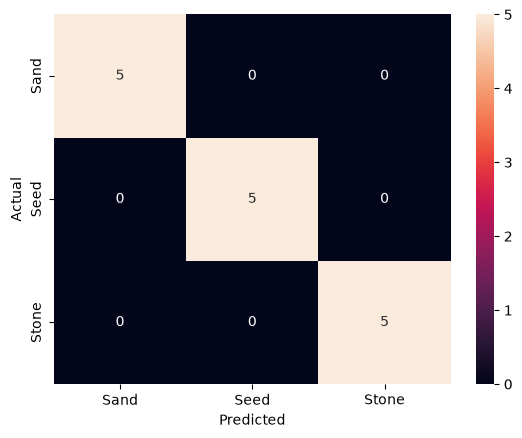

In [17]:
# test set evaluation
prediction = clf.predict(vec_test)
# visualization
cmat = metrics.confusion_matrix(prediction,label_test)
s = sns.heatmap(cmat,annot=True,xticklabels=labels, yticklabels=labels)
s.set(xlabel='Predicted', ylabel='Actual')
acc = cmat.trace() / cmat.sum()
print('Accuracy: {0:5.2f}%'.format(acc*100))